### Naive Bayes Classifier

This notebook provides a hands-on implementation of the Naive Bayes algorithm.
  
The workflow includes:
- Explaining the basic concept of Naive Bayes  
- Implementing the algorithm manually  
- Training and testing the model on a medical dataset  
- Measuring its accuracy and visualizing the outcomes

### Objective
The main goal is to **learn how Naive Bayes works internally** — how probabilities are calculated and how predictions are made based on conditional likelihoods.


Import libraries

In [1]:
import pandas as pd
import naive_bayes_classifier as nb
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset

In this step, we load the dataset **`inflammation_diagnosis.csv`** using `pandas`.  
- The file is read with a semicolon (`;`) as the separator.  
- The first few rows of the dataset are displayed using `data.head()` to get an overview of the columns and sample values.


In [2]:
data = pd.read_csv("inflammation_diagnosis.csv", sep=';')
print('\n',data.head())


    temperature nausea lumbar_pain urine_pushing micturition_pains  \
0         35.5     no         yes            no                no   
1         35.9     no          no           yes               yes   
2         35.9     no         yes            no                no   
3         36.0     no          no           yes               yes   
4         36.0     no         yes            no                no   

  burning_of_urethra inflammation nephritis  
0                 no           no        no  
1                yes          yes        no  
2                 no           no        no  
3                yes          yes        no  
4                 no           no        no  


### Check for Missing Values

We check if the dataset contains any **missing (null) values** in each column using `data.isnull().sum()`.  
- This helps identify incomplete or missing data that may need to be handled before model training.  
- The output shows the number of missing entries for each column.


In [3]:
print('\n\nMissing value :\n', data.isnull().sum())



Missing value :
 temperature           0
nausea                0
lumbar_pain           0
urine_pushing         0
micturition_pains     0
burning_of_urethra    0
inflammation          0
nephritis             0
dtype: int64


### Create the `disease` Feature

In this step, we create a new feature called **`disease`** based on the two medical indicators — **`inflammation`** and **`nephritis`**.

- First, both columns are standardized by capitalizing their text values (e.g., `'yes'` = `'Yes'`).
- Then, the new column **`disease`** is defined as `True` if either `inflammation` or `nephritis` is `'Yes'`, and `False` otherwise.
- The original columns (`inflammation` and `nephritis`) are then removed to avoid redundancy.
- Finally, we display the first 20 rows to verify the new `disease` feature.


In [4]:
data['inflammation'] = data['inflammation'].str.capitalize()
data['nephritis'] = data['nephritis'].str.capitalize()

data['disease'] = (data['inflammation'] == 'Yes') | (data['nephritis'] == 'Yes')
data = data.drop(columns=['inflammation', 'nephritis'])
print('\n',data.head(20))


     temperature nausea lumbar_pain urine_pushing micturition_pains  \
0          35.5     no         yes            no                no   
1          35.9     no          no           yes               yes   
2          35.9     no         yes            no                no   
3          36.0     no          no           yes               yes   
4          36.0     no         yes            no                no   
5          36.0     no         yes            no                no   
6          36.2     no          no           yes               yes   
7          36.2     no         yes            no                no   
8          36.3     no          no           yes               yes   
9          36.6     no          no           yes               yes   
10         36.6     no          no           yes               yes   
11         36.6     no         yes            no                no   
12         36.6     no         yes            no                no   
13         36.7   

### Split the Dataset into Training and Testing Sets

In this step, we divide the dataset into two parts:
- **Training set (80%)** – used to train the Naive Bayes model  
- **Testing set (20%)** – used to evaluate model performance  

A fixed `random_state` is used to ensure reproducibility.  
Finally, we print the number of samples in each set to confirm the split.

In [6]:
train_data = data.sample(frac=0.8, random_state=42)
test_data= data.drop(train_data.index)

print('Train size : ', len(train_data))
print('Test size : ', len(test_data))

Train size :  96
Test size :  24


### Verify Dataset Split Integrity

This step checks whether the **training** and **testing** datasets share any common rows (indices).  
- Using `isdisjoint()` ensures that there is **no overlap** between the two datasets.  
- If the datasets are completely separate, it prints **"No overlap detected"**, confirming a valid split.  
- If any indices overlap, it prints **"Overlap detected!"**, indicating a potential data leakage issue.


In [7]:
if set(train_data.index).isdisjoint(test_data.index):
    print('No overlap detected')
else:
    print('Overlap detected!')

No overlap detected


### Create the `continuous` Feature List

Before training the model, we identify which columns are **continuous** and which are **discrete**.

- We remove the target column `disease` to focus only on the feature columns.  
- For each column:
  - If it is **numeric** and has **more than 10 unique values**, it is classified as a **continuous feature** (`True`).  
  - Otherwise, it is treated as a **discrete feature** (`False`).  
- The results are stored in a list called `continuous`, which will later be passed to the Naive Bayes model to handle each feature appropriately.


In [ ]:
continuous = []
train_continuous = data.drop(columns="disease")
for i in train_continuous.columns:
    if pd.api.types.is_numeric_dtype(train_continuous[i]) and train_continuous[i].nunique() > 10:
        continuous.append(True)
    else:
        continuous.append(False)

print(continuous)

[True, False, False, False, False, False]


### Train the Naive Bayes Model

We now create an instance of the `NaiveBayes` class and train it on the **training dataset**.  
- The `continuous` list indicates which features are continuous or discrete.  
- The model is trained using the `fit()` method, with **`disease`** as the target column.

In [9]:
model = nb.NaiveBayes(continuous) # created object of class
model.fit(train_data, target_name='disease')


Return class :  True
Print Feature table : 
     temperature nausea lumbar_pain urine_pushing micturition_pains  \
44         37.5     no          no           yes                no   
47         37.6     no          no           yes               yes   
55         37.9     no          no           yes               yes   
26         37.0     no          no           yes               yes   
64         38.5     no         yes           yes                no   
10         36.6     no          no           yes               yes   
18         36.9     no          no           yes               yes   
62         38.1     no         yes           yes                no   
36         37.3     no          no           yes                no   
89         40.6    yes         yes           yes               yes   

   burning_of_urethra  
44                 no  
47                yes  
55                 no  
26                yes  
64                yes  
10                yes  
18             

### Make Predictions on Test Data

In this step, we use the trained Naive Bayes model to make predictions on the **test dataset**.

- The target column `disease` is removed before prediction since the model only needs feature inputs.  
- The `predict_probability()` method calculates the probability of each class (disease or no disease) for every test sample and assigns the most likely class as the prediction.  
- Finally, we print a message indicating that the model evaluation on the test data has started.


In [10]:
model.predict_probability(test_data.drop(columns=['disease']))
print('\nEvalueation on Test Data ')


Index of Rows : 1
Row :
 temperature           35.9
nausea                  no
lumbar_pain             no
urine_pushing          yes
micturition_pains      yes
burning_of_urethra     yes
Name: 1, dtype: object

Starting probability :  True  :  0.7604166666666666

Feature :  temperature , Value :  35.9
Multiply by Gaussian (continuous feature) :  temperature 35.9 True 0.05291804478812144

Feature :  nausea , Value :  no
Multiply by P nausea  =  no  /  True = 0.6986301369863014

Feature :  lumbar_pain , Value :  no
Multiply by P lumbar_pain  =  no  /  True = 0.4657534246575342

Feature :  urine_pushing , Value :  yes
Multiply by P urine_pushing  =  yes  /  True = 0.9041095890410958

Feature :  micturition_pains , Value :  yes
Multiply by P micturition_pains  =  yes  /  True = 0.6438356164383562

Feature :  burning_of_urethra , Value :  yes
Multiply by P burning_of_urethra  =  yes  /  True = 0.5616438356164384

Starting probability :  False  :  0.23958333333333334

Feature :  temperature

### Evaluate the Model on Test Data

Now we evaluate the performance of the trained Naive Bayes model using the **testing dataset**.

- The test dataset (`test_data`) contains both features and the actual target labels (`disease`).  
- The `evaluate_on_data()` method:
  - Predicts the labels for all test samples.  
  - Compares them with the actual labels to calculate **accuracy**.  
  - Generates a **confusion matrix** showing counts of:
    - **True Positives (TP)** — correctly predicted disease cases  
    - **True Negatives (TN)** — correctly predicted non-disease cases  
    - **False Positives (FP)** — predicted disease but actually healthy  
    - **False Negatives (FN)** — predicted healthy but actually diseased  

The function returns both the overall **accuracy** and the **confusion matrix** as output.


In [11]:
test_data

,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_of_urethra,disease
1,35.9,no,no,yes,yes,yes,True
2,35.9,no,yes,no,no,no,False
14,36.7,no,yes,no,no,no,False
20,37.0,no,no,yes,yes,no,True
21,37.0,no,no,yes,yes,no,True
23,37.0,no,no,yes,yes,yes,True
29,37.1,no,no,yes,yes,yes,True
37,37.4,no,yes,no,no,no,False
51,37.7,no,no,yes,no,no,True
52,37.8,no,yes,no,no,no,False


In [12]:
accuracy, confusion = model.evaluate_on_data(test_data, test_labels='disease')


Index of Rows : 1
Row :
 temperature           35.9
nausea                  no
lumbar_pain             no
urine_pushing          yes
micturition_pains      yes
burning_of_urethra     yes
Name: 1, dtype: object

Starting probability :  True  :  0.7604166666666666

Feature :  temperature , Value :  35.9
Multiply by Gaussian (continuous feature) :  temperature 35.9 True 0.05291804478812144

Feature :  nausea , Value :  no
Multiply by P nausea  =  no  /  True = 0.6986301369863014

Feature :  lumbar_pain , Value :  no
Multiply by P lumbar_pain  =  no  /  True = 0.4657534246575342

Feature :  urine_pushing , Value :  yes
Multiply by P urine_pushing  =  yes  /  True = 0.9041095890410958

Feature :  micturition_pains , Value :  yes
Multiply by P micturition_pains  =  yes  /  True = 0.6438356164383562

Feature :  burning_of_urethra , Value :  yes
Multiply by P burning_of_urethra  =  yes  /  True = 0.5616438356164384

Starting probability :  False  :  0.23958333333333334

Feature :  temperature

### Visualize the Confusion Matrix

To better understand the model’s performance, we visualize the **confusion matrix** using a heatmap.

- The confusion matrix displays the counts of:
  - **True Positives (TP)**
  - **False Positives (FP)**
  - **False Negatives (FN)**
  - **True Negatives (TN)**
- A **heatmap** is plotted using `seaborn` (`sns.heatmap`) to show these values in a clear, color-coded format.  
- The x-axis represents the **predicted labels**


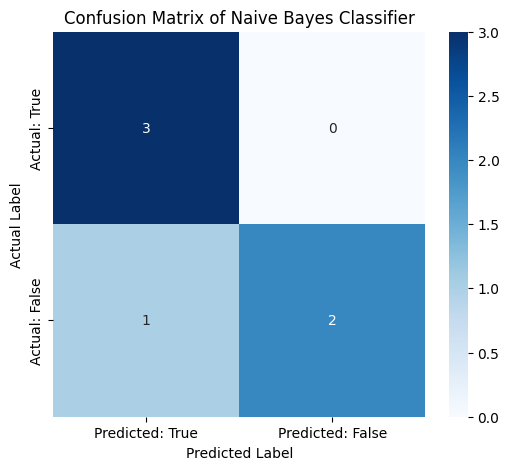

In [13]:
conf_matrix = [
    [confusion['True_Positive'], confusion['False_Positive']],
    [confusion['False_Negative'], confusion['True_Negative']]
]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: True', 'Predicted: False'], 
            yticklabels=['Actual: True', 'Actual: False'])
plt.title('Confusion Matrix of Naive Bayes Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Visualize Model Accuracy

To summarize the model’s performance, we plot the **accuracy** of the Naive Bayes classifier using a simple bar chart.

- The bar chart shows the overall **accuracy percentage** achieved by the model on the test dataset.  


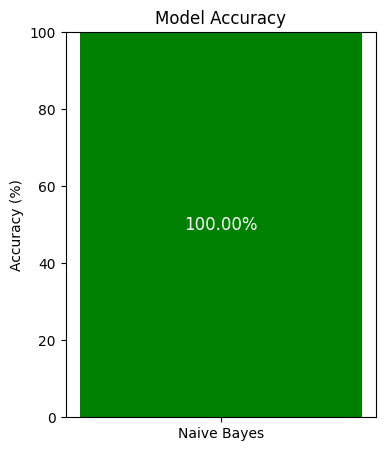

In [14]:
plt.figure(figsize=(4, 5))
plt.bar(['Naive Bayes'], [accuracy * 100], color='green')
plt.title('Model Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.text(0, accuracy * 100 / 2, f"{accuracy*100:.2f}%", ha='center', va='center', color='white', fontsize=12)
plt.show()